# Nonstationary Mpemba relaxation in a driven collective-spin model

**Paper companion.** Appendix A and Fig. S1 in the supplementary
numbering; Eq. (A4) and Fig. 14 in the published article.

This notebook constructs the all-to-all Rydberg-like model in the
maximal-spin sector, finds its nonthermal stationary state, and
generates both pure initial states from a documented slow-mode
selection rule. It therefore replaces the opaque
`FigS1_data.pkl` dependency of the original figure notebook.

**Reproduction status.** Independent reconstruction at the published
parameters. No state, trajectory, or fitted curve is loaded.

**Reference.** A. Summer *et al.*, *Phys. Rev. X* **16**, 011065
(2026), [doi:10.1103/rbt4-psfd](https://doi.org/10.1103/rbt4-psfd).


In [1]:
import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as la

_HERE = Path.cwd().resolve()
for _candidate in [_HERE, *_HERE.parents]:
    if (_candidate / "tools" / "notebook_utils.py").exists():
        _TOOLS_DIR = _candidate / "tools"
        break
else:
    raise RuntimeError(
        "Could not locate tools/notebook_utils.py from cwd or its parents."
    )
if str(_TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(_TOOLS_DIR))

import notebook_utils as nu

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=5, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.2, 4.2),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "font.size": 11,
})

BLUE = "#394F87"
ORANGE = "#E8792E"
GREEN = "#3A7D44"
PURPLE = "#7C4D9E"


## 1. Model and nonthermal stationary state

In the symmetric sector \(j=N_s/2\), the Hilbert-space dimension is
only \(N_s+1\). The model is

$$
H=\Omega S_x-\Delta S_z+\frac{V}{N_s}S_z^2,\qquad
L_1=\sqrt{\kappa}\,S_- .
$$

Its unique fixed point is not a Gibbs state of \(H\). The resource
monotone is consequently the nonstationarity
\(M(\rho)=S(\rho\Vert\pi)\).


In [2]:
N_S = 5
OMEGA = 1.0
DELTA = -1.0
V = 3.0
KAPPA = 0.01

Sx, Sy, Sz = nu.spin_j_operators(N_S)
Sminus = Sx - 1j * Sy
H = OMEGA * Sx - DELTA * Sz + (V / N_S) * (Sz @ Sz)
L = nu.lindblad_liouvillian(
    H, [np.sqrt(KAPPA) * Sminus]
)
pi = nu.stationary_density(L, N_S + 1)

nu.validate_density(pi)
assert la.norm(L @ nu.vec(pi)) < 1e-9
assert not np.allclose(pi, nu.gibbs_state(H, 1.0), atol=1e-3)

print(f"Symmetric-sector dimension: {N_S + 1}")
print("Stationary-state eigenvalues:")
print(la.eigvalsh(pi))


Symmetric-sector dimension: 6
Stationary-state eigenvalues:
[0.      0.00014 0.12735 0.22263 0.25024 0.39964]


## 2. Auditable initial-state protocol

The paper specifies that the pair is chosen to have opposite initial
and asymptotic orderings, but the archived pickle contains no random
seed or preparation metadata. We make that selection rule executable:

- draw a fixed-seed pool of Haar-distributed pure states;
- among the lowest quartile of overlaps with the slowest decaying
  left mode, choose the state with largest \(S(\rho\Vert\pi)\);
- choose the comparison state from the highest overlap quintile,
  subject to smaller initial nonstationarity.

This is a deterministic implementation of the slow-mode protocol,
rather than a fit to the plotted curves.


In [3]:
eigenvalues, left_modes, right_modes = la.eig(
    L, left=True, right=True
)
decaying = [
    index
    for index in np.argsort(eigenvalues.real)[::-1]
    if eigenvalues[index].real < -1e-10
]
slow_index = decaying[0]
slow_left = left_modes[:, slow_index]
slow_left /= la.norm(slow_left)

rng = np.random.default_rng(20_260_727)
pool_size = 4_000
kets = rng.normal(size=(pool_size, N_S + 1))
kets = kets + 1j * rng.normal(size=kets.shape)
kets /= la.norm(kets, axis=1)[:, None]

log_pi = la.logm(pi)
initial_resources = np.real(
    -np.einsum("bi,ij,bj->b", kets.conj(), log_pi, kets)
)
density_vectors = np.stack(
    [nu.vec(np.outer(ket, ket.conj())) for ket in kets]
)
slow_overlaps = np.abs(density_vectors @ slow_left.conj())

low_threshold = np.quantile(slow_overlaps, 0.25)
high_threshold = np.quantile(slow_overlaps, 0.80)
fast_candidates = np.flatnonzero(
    slow_overlaps <= low_threshold
)
fast_index = fast_candidates[
    np.argmax(initial_resources[fast_candidates])
]
reference_candidates = np.flatnonzero(
    (slow_overlaps >= high_threshold)
    & (initial_resources < initial_resources[fast_index])
)
reference_index = reference_candidates[
    np.argmax(
        slow_overlaps[reference_candidates]
        / initial_resources[reference_candidates]
    )
]

ket_1 = kets[fast_index]
ket_2 = kets[reference_index]
rho_1 = np.outer(ket_1, ket_1.conj())
rho_2 = np.outer(ket_2, ket_2.conj())

print(f"Slow eigenvalue: {eigenvalues[slow_index]:.7g}")
print(
    "rho_1: "
    f"M(0)={initial_resources[fast_index]:.5f}, "
    f"slow overlap={slow_overlaps[fast_index]:.5f}"
)
print(
    "rho_2: "
    f"M(0)={initial_resources[reference_index]:.5f}, "
    f"slow overlap={slow_overlaps[reference_index]:.5f}"
)
assert initial_resources[fast_index] > initial_resources[reference_index]
assert slow_overlaps[fast_index] < slow_overlaps[reference_index]


Slow eigenvalue: -0.01387526-4.851121e-17j
rho_1: M(0)=9.74433, slow overlap=0.11383
rho_2: M(0)=1.46488, slow overlap=0.36137


## 3. Relative-entropy relaxation

The two states evolve under the same CPTP semigroup. The initially
more nonstationary state has less weight in the slowest mode, so its
late-time relative entropy is smaller.


In [4]:
times = np.linspace(0, 400, 1_001)
states_1 = nu.evolve_density(L, rho_1, times)
states_2 = nu.evolve_density(L, rho_2, times)
resource_1 = np.asarray(
    [nu.quantum_relative_entropy(state, pi) for state in states_1]
)
resource_2 = np.asarray(
    [nu.quantum_relative_entropy(state, pi) for state in states_2]
)
tau = nu.crossing_time(times, resource_1, resource_2)
crossing_resource = np.interp(tau, times, resource_1)

assert np.isfinite(tau)
assert resource_1[0] > resource_2[0]
assert resource_1[-1] < resource_2[-1]
print(f"Crossing: t={tau:.3f}, kappa*t={KAPPA * tau:.3f}")


Crossing: t=142.631, kappa*t=1.426


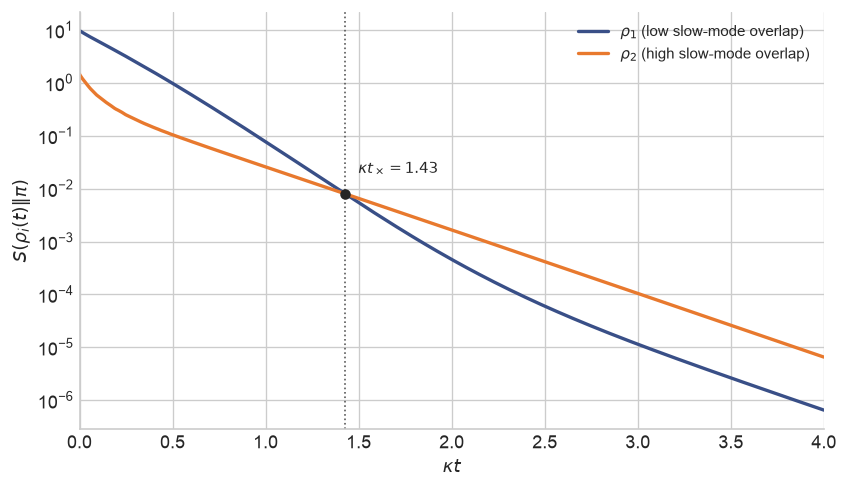

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.semilogy(
    KAPPA * times,
    np.maximum(resource_1, 1e-15),
    color=BLUE,
    lw=2,
    label=r"$\rho_1$ (low slow-mode overlap)",
)
ax.semilogy(
    KAPPA * times,
    np.maximum(resource_2, 1e-15),
    color=ORANGE,
    lw=2,
    label=r"$\rho_2$ (high slow-mode overlap)",
)
ax.axvline(KAPPA * tau, color="0.35", ls=":", lw=1)
ax.scatter(
    [KAPPA * tau],
    [crossing_resource],
    s=28,
    color="0.15",
    zorder=5,
)
ax.annotate(
    fr"$\kappa t_\times={KAPPA * tau:.2f}$",
    xy=(KAPPA * tau, crossing_resource),
    xytext=(8, 12),
    textcoords="offset points",
    fontsize=9,
)
ax.set(
    xlabel=r"$\kappa t$",
    ylabel=r"$S(\rho_i(t)\Vert\pi)$",
    xlim=(KAPPA * times[0], KAPPA * times[-1]),
)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()


**Figure.** Relative entropy to the unique nonthermal stationary
state. The more resourceful blue state suppresses the slow mode and
overtakes the orange state at the marked crossing.

## Result

Thermal equilibrium is not required for a Mpemba effect. Relative
entropy to a unique nonthermal stationary state is a nonstationarity
monotone, and suppressing the slow Liouvillian overlap reverses the
relaxation ordering. Here the crossing occurs at
\(\kappa t_\times\simeq1.43\). Every numerical input is constructed
above; the archived `FigS1_data.pkl` is not read.
